# Burn severity and erosion priority after the Vesuvius fire of August 2025

**The event.** A fire burned above Terzigno, on the south-east flank of Vesuvius, for four days from 8 August 2025. Copernicus EMS activation EMSR830 opened on 9 August. Press reports put the loss at about 500 hectares of pine and shrub.

**The question.** Which slopes should the park authority and the Campania civil protection treat first, before the autumn rains wash the ash off steep ground?

**The method**
1. Download Sentinel-2 images from before and after the fire.
2. Score burn severity per pixel with dNBR.
3. Add slope from the Copernicus DEM.
4. Rank 250 m cells by severe burn on steep ground.

**The outputs**
- A ranked table of cells.
- A GeoJSON of the flagged cells.
- A plain-language summary, written by code, not by a language model. The LLM version is bonus A.

**Data.** Microsoft Planetary Computer: Sentinel-2 L2A and Copernicus DEM GLO-30, processed locally. No account or API key.

**Run.** Python 3.12, then

```bash
pip install -r requirements.txt
pip install -e .
```

and run all cells. The README has the Colab variant.

## 1. Where, when and the rules

Every constant is set once, with its reason, in `src/burnsev/aoi.py`. Change one there and rerun.

| Setting | Value |
|---|---|
| **Box** | 14.35 to 14.50 E, 40.77 to 40.87 N: about 13 by 11 km around the cone and its south-east flank |
| **Pre-fire window** | 1 July to 7 August 2025 (scenes loaded from 1 June, to show the trend) |
| **Post-fire window** | 13 August to 15 September 2025 (scenes loaded to 15 October, to show the recovery) |
| **Severity** | dNBR in the five classes of Key and Benson (2006) |
| **Priority** | moderate or high severity (dNBR >= 0.27) on slope >= 23 degrees: the terrain term of USGS model M1 (Staley et al. 2017) |

Only the terrain term is computed. The full model also needs rainfall intensity and soil erodibility.

In [1]:
# Step 1. Every number a user might want to change lives in src/burnsev/aoi.py, with its reason next to it.
from burnsev import aoi

print("AOI (west, south, east, north):", aoi.BBOX)
print("Fire:", aoi.FIRE_START, "to", aoi.FIRE_END)
print("Pre-fire window: ", *aoi.PRE_WINDOW)
print("Post-fire window:", *aoi.POST_WINDOW)
print("Bands:", aoi.BANDS, "at", aoi.RESOLUTION, "m in", aoi.CRS)
print("Severe = dNBR >=", aoi.SEVERITY_CUT_DNBR, "->", aoi.SEVERE_CLASSES)
print("Steep  = slope >=", aoi.SLOPE_THRESHOLD_DEG, "deg; sensitivity at", aoi.SLOPE_SENSITIVITY_DEG)

# The libraries that did the geospatial work, for anyone comparing runs.
import odc.stac
import pyproj
import rasterio

print("odc-stac", odc.stac.__version__, "| rasterio", rasterio.__version__,
      "| GDAL", rasterio.__gdal_version__, "| PROJ", pyproj.proj_version_str)

AOI (west, south, east, north): (14.35, 40.77, 14.5, 40.87)
Fire: 2025-08-08 to 2025-08-12
Pre-fire window:  2025-07-01 2025-08-07
Post-fire window: 2025-08-13 2025-09-15
Bands: ['B02', 'B03', 'B04', 'B8A', 'B11', 'B12', 'SCL'] at 20 m in EPSG:32633
Severe = dNBR >= 0.27 -> ('moderate-low', 'moderate-high', 'high')
Steep  = slope >= 23.0 deg; sensitivity at (20.0, 23.0, 26.0)
odc-stac 0.5.3 | rasterio 1.5.1 | GDAL 3.12.4 | PROJ 9.8.1


## 2. Which scenes exist

A STAC search on Microsoft Planetary Computer returns the Sentinel-2 L2A products covering the box in each window, metadata only. The same search works on any STAC catalogue.

**The scene table** records date, satellite, orbit, cloud cover and processing version.

**Two choices**
- The 25 percent cloud ceiling is a coarse, tile-level filter. The real cleaning is per pixel in step 3.
- The offset is read per product, not assumed, because Sentinel-2 changed its number format in 2022.

In [2]:
# Step 2. Ask the catalogue which scenes exist over the box in each window. Metadata only, no pixels yet.
from burnsev import catalog

pre_items = catalog.search_scenes(aoi.BBOX, aoi.SERIES_START, aoi.PRE_WINDOW[1], aoi.MAX_CLOUD)
post_items = catalog.search_scenes(aoi.BBOX, aoi.POST_WINDOW[0], aoi.SERIES_END, aoi.MAX_CLOUD)
print(len(pre_items), "pre-fire and", len(post_items), "post-fire scenes under", aoi.MAX_CLOUD, "% cloud")

scenes = catalog.scene_table(pre_items + post_items)
scenes

32 pre-fire and 23 post-fire scenes under 25.0 % cloud


,id,date,satellite,orbit,tile,cloud_pct,baseline,boa_add_offset
0,S2C_MSIL2A_20250605T095051_R079_T33TVF_2025060...,2025-06-05,Sentinel-2C,79,33TVF,1.8,05.11,-1000
1,S2A_MSIL2A_20250607T095041_R079_T33TVF_2025060...,2025-06-07,Sentinel-2A,79,33TVF,0.0,05.11,-1000
2,S2A_MSIL2A_20250607T095041_R079_T33TVF_2025060...,2025-06-07,Sentinel-2A,79,33TVF,0.0,05.11,-1000
3,S2C_MSIL2A_20250608T100051_R122_T33TVF_2025060...,2025-06-08,Sentinel-2C,122,33TVF,9.5,05.11,-1000
4,S2B_MSIL2A_20250610T095029_R079_T33TVF_2025061...,2025-06-10,Sentinel-2B,79,33TVF,2.5,05.11,-1000
5,S2A_MSIL2A_20250610T100041_R122_T33TVF_2025061...,2025-06-10,Sentinel-2A,122,33TVF,2.4,05.11,-1000
6,S2B_MSIL2A_20250613T100029_R122_T33TVF_2025061...,2025-06-13,Sentinel-2B,122,33TVF,0.2,05.11,-1000
7,S2C_MSIL2A_20250615T095051_R079_T33TVF_2025061...,2025-06-15,Sentinel-2C,79,33TVF,0.6,05.11,-1000
8,S2A_MSIL2A_20250617T095051_R079_T33TVF_2025061...,2025-06-17,Sentinel-2A,79,33TVF,12.6,05.11,-1000
9,S2B_MSIL2A_20250620T095029_R079_T33TVF_2025062...,2025-06-20,Sentinel-2B,79,33TVF,1.5,05.11,-1000


**What the table shows**
- **55 products:** 32 pre-fire, 23 post-fire, all under 25 percent cloud.
- **Three satellites** (Sentinel-2A, 2B, 2C) on **two orbits** (79, 122) ten minutes apart, so some dates appear twice.
- **First post-fire scene:** 14 August, two days after containment.
- **Baseline 05.11 throughout.** Baseline 04.00 (January 2022) added 1000 to every stored value, so the offset is minus 1000, read from metadata.
- **7 June** was published twice, 90 minutes apart. Step 3 groups by solar day, so it counts once.
- **Cloud filter** on the returned metadata, in Python: this catalogue does not advertise the STAC query extension.

**Next.** Download the pixels of these 55 products, mask clouds per pixel, convert to reflectance.

## 3. Load the pixels and mask the clouds

**The cube.** odc-stac reads only the box from the band files of the 55 products, into one cube per band: shape (46, 560, 637) at 20 m in UTM zone 33.
- No reprojection: the files are already in UTM zone 33.
- The three 10 m bands are averaged to 20 m, the native size of B8A and B12.
- Same-day products are fused, first valid pixel wins.
- The download is cached. Everything after it is recomputed each run.

![One stack per band](docs/figures/cube.png)

**Three steps on the raw numbers**
- **Reflectance.** (DN + BOA_ADD_OFFSET) / 10,000. The offset is minus 1,000 for all 55 products (baseline 05.11).
- **Cloud mask** from SCL: no data, saturated, cloud shadow, cloud, thin cirrus and snow are blanked. Water and dark pixels are kept: SCL is built for the atmospheric correction, [not as a land cover map](https://sentinel.esa.int/en/web/sentinel/user-guides/sentinel-2-msi/processing-levels/level-2), and on 19 August it labels a quarter of the burn as water.
- **Quality.** The usable pixel share per date is kept.

{'y': 560, 'x': 637, 'time': 46} | EPSG 32633 | reflectance cube 394 MB


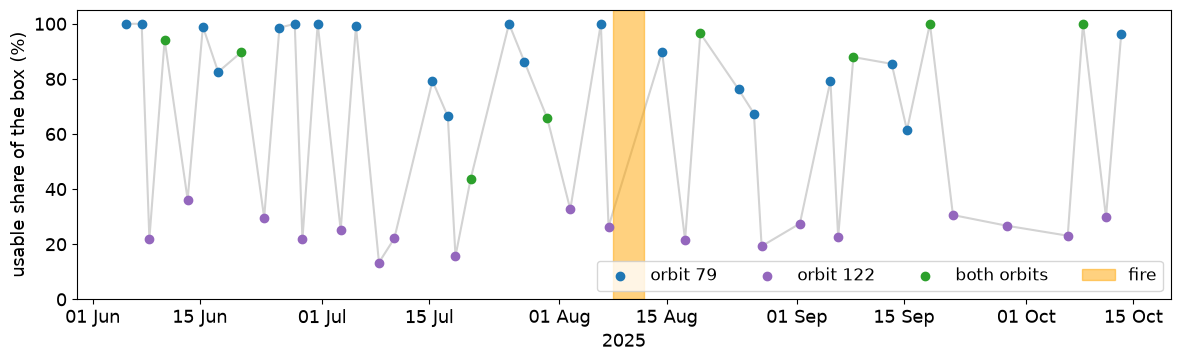

In [3]:
# Step 3. Download the pixels once (cached), then mask clouds with SCL and convert to reflectance.
from burnsev import ingest, plots

cube_file = ingest.cache_path("s2_dn_20m")
dn = ingest.load_cached(cube_file)
if dn is None:
    dn = ingest.load_cube(pre_items + post_items)  # digital numbers, one time step per solar day
    ingest.save_cube(dn, cube_file)

refl = ingest.mask_and_scale(dn, catalog.offsets_by_day(pre_items + post_items))
print(dict(refl.sizes), "| EPSG", refl.odc.crs.epsg, "| reflectance cube", round(refl.nbytes / 1e6), "MB")
fig = plots.usable_share(refl, catalog.orbits_by_day(pre_items + post_items), (aoi.FIRE_START, aoi.FIRE_END))

**What the run shows**
- **46 dates** from 55 products: 27 pre-fire, 19 post-fire. Ten pre-fire and four post-fire dates see the whole box.
- **Two orbits.** Orbit 79 covers the whole box; its dips on 20 July and 15 September are cloud. Orbit 122 sees only the western fifth, 20 to 35 percent on every date.
- **No date is dropped.** Step 5 takes medians per pixel over the available dates. The east is seen only by orbit 79.

**Next.** True colour before and after, one stretch for both dates.

## 4. Look before and after

**Dates.** 6 August, two days before the reported start, and 14 August, two days after containment, the first fully clear date over the burn.

**Stretch.** Each band is stretched between its 2nd and 98th percentile (the QGIS default): land reflectance sits mostly between 0.02 and 0.30, so the full 0 to 1 range would look almost black.
- The bounds come from the pre-fire image and are reused on the post-fire one, so the pair stays comparable.
- Masked pixels are light grey. The stretch is display only.

**Second row.** Short-wave infrared: B12 as red, B8A as green, B04 as blue. Healthy vegetation is bright in the near infrared and dark in the short-wave infrared, so it shows green. Burned ground is the opposite and shows dark red. That is the contrast the burn index in step 5 turns into a number.

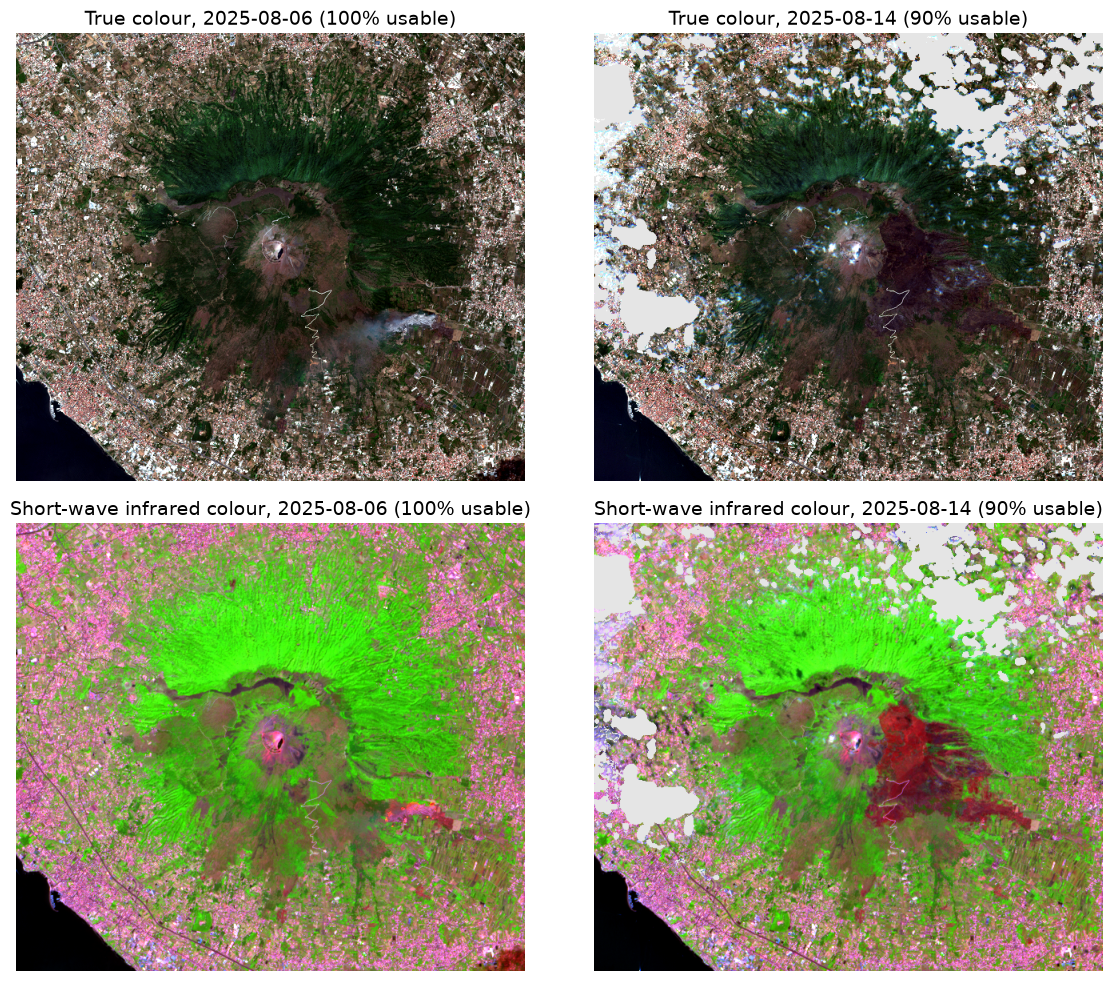

In [4]:
# Step 4. The clearest dates closest to the fire, in true colour and in short-wave infrared colour.
pre_day, post_day = "2025-08-06", "2025-08-14"
fig = plots.before_after(refl, pre_day, post_day)

**What the pictures show**
- **The burn** is a dark brown patch on the south-east flank, dark red in short-wave infrared against bright green forest.
- **6 August.** A smoke plume and a small dark red patch sit at the eastern edge of the future burn. Mean NBR inside the burn on that date is 0.39, close to the 0.43 of 25 July: the main fire came later, and one early date does not shift the pre-fire median.
- **14 August.** The clouds sit north of the cone, outside the burn, every burn pixel usable. 19 August, 24 August and 8 September are cloudier over the burn, hence this pair. 18 September is the next fully clear date.
- **Ash as water.** On 19 August the scene classification labels a quarter of the burn as water: fresh ash is as dark as water. Water stays out of the mask so a burn scar is not discarded as a lake.

**Next.** Turn the contrast into a number per pixel: NBR on each date, medians before and after, dNBR as their difference.

## 5. Composites, NBR and dNBR

**NBR** = (B8A - B12) / (B8A + B12): high for live vegetation, low for bare or charred ground. The sum cancels brightness differences between dates. Computed per pixel, per date.

**Median composites.** Each window becomes one median per pixel, not a mean: one odd date (haze, a missed cloud edge, the small fire of 6 August) cannot move it.

**Windows: 1 July to 7 August before, 13 August to 15 September after.** A median summarises a window well only when the window is stable. Before the fire, NBR inside the future burn slides through June while the unburned reference stays flat, so the pre-fire window starts in July. After the fire, recovery starts within weeks as ash washes off and grass returns, so the post-fire window is one month, the timing of the Key and Benson initial assessment. Scenes are loaded from 1 June to 15 October so the plot shows both trends.

**dNBR** = median before minus median after. Positive means vegetation lost; step 6 classifies it.

The cell prints the source of both functions, so the formula on this page is the code that ran, and counts the usable observations behind each pixel.

def nbr(ds: xr.Dataset) -> xr.DataArray:
    """Normalised Burn Ratio, (B8A - B12) / (B8A + B12), per pixel and date.

    Healthy vegetation is bright in the near infrared (B8A) and dark in the short-wave
    infrared (B12), so NBR is high. Burned ground is the reverse, so NBR drops after a fire.
    """
    return normalised_difference(ds["B8A"], ds["B12"]).rename("NBR")

def dnbr(nbr_da: xr.DataArray, pre: tuple[str, str], post: tuple[str, str]) -> xr.DataArray:
    """dNBR = median NBR before the fire minus median NBR after it. Positive means burned.

    Differencing removes what the two composites share (soil colour, terrain, the sensor)
    and keeps the change, which is what the severity classes are defined on.
    """
    return (window_median(nbr_da, *pre) - window_median(nbr_da, *post)).rename("dNBR")

pre-fire: usable observations per pixel, min 2, median 7, max 14
post-fire: usable observations per pixel, min 1, median 7, max 12


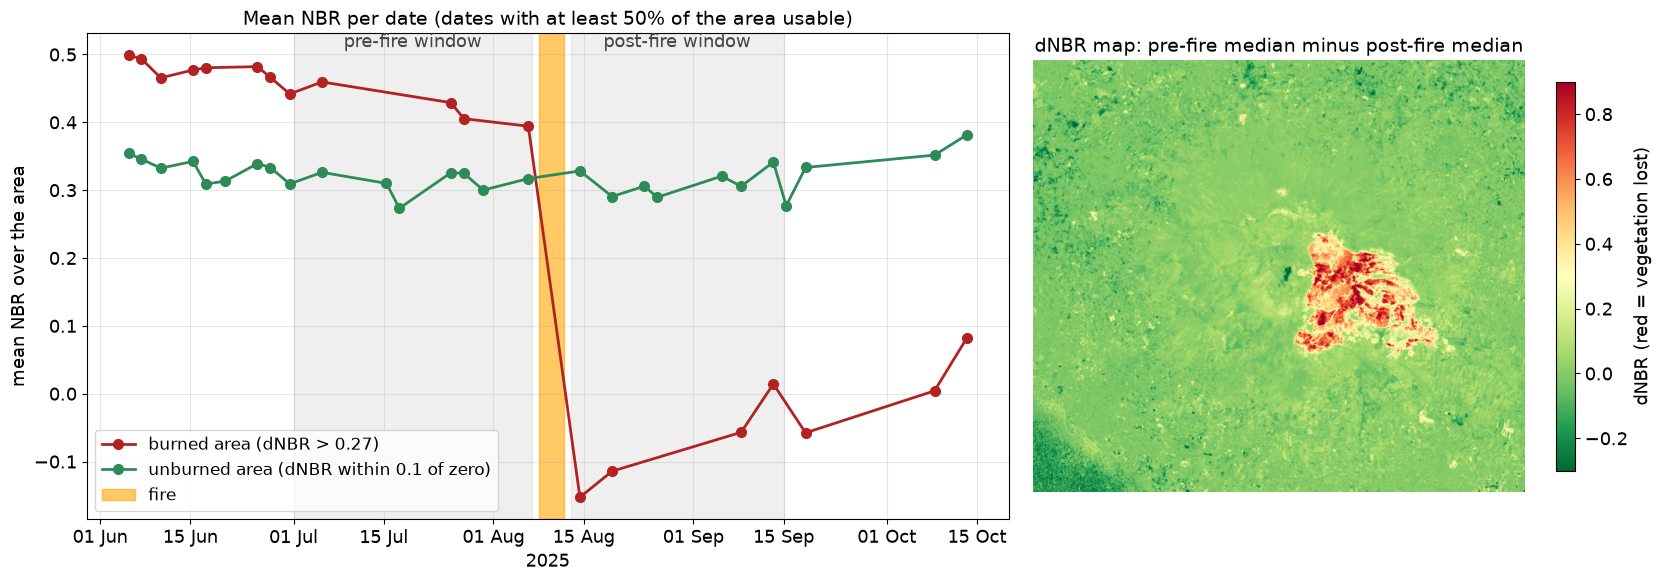

In [5]:
# Step 5. NBR per pixel and date, the median of each window, and dNBR = before minus after.
import inspect

from IPython.display import Code, display

from burnsev import indices


def show(fn):
    """The source of a function, shown next to the cell that calls it."""
    return Code(inspect.getsource(fn), language="python")


display(show(indices.nbr), show(indices.dnbr))
nbr = indices.nbr(refl)
dnbr = indices.dnbr(nbr, aoi.PRE_WINDOW, aoi.POST_WINDOW)
for label, window in (("pre-fire", aoi.PRE_WINDOW), ("post-fire", aoi.POST_WINDOW)):
    n = indices.window_count(nbr, *window)
    print(f"{label}: usable observations per pixel, min {int(n.min())}, median {int(n.median())}, max {int(n.max())}")

burn = dnbr > aoi.SEVERITY_CUT_DNBR
fire = (aoi.FIRE_START, aoi.FIRE_END)
fig = plots.nbr_history_and_dnbr(nbr, dnbr, burn, aoi.PRE_WINDOW, aoi.POST_WINDOW, fire)

**What the run shows**
- Usable observations per pixel: pre-fire min 2, median 7; post-fire min 1, median 7.
- Inside the burn (dNBR > 0.27, 591 ha), median NBR falls from 0.44 before the fire to -0.10 after; by 13 October it is back to 0.08. The unburned area stays at 0.33 before and 0.32 after, so the drop is the fire, not the season.
- Pre-fire window: the June points sit above the July shading. NBR inside the future burn slides from 0.50 on 5 June to 0.39 on 6 August. A June start would give 637 ha of severe burn instead of 591.
- Post-fire window: recovery starts within weeks, so the window ends on 15 September. A median to 15 October would give 564 ha with a high class of 91 ha instead of 149 ha; the first clear observation per pixel gives 628 ha and 204 ha.
- dNBR inside the burn: median 0.51, 90th percentile 0.79.

**Next.** Classes and hectares per class.

## 6. Severity classes and areas

> _Narration drafted when this step is built._ Key and Benson classes; map and a table of hectares per class.

In [6]:
# Step 6: written after step 5 is approved.

> _What the result shows and what it means for the next step: written after this step runs._

## 7. Check against the EFFIS perimeter

> _Narration drafted when this step is built._ Independent reference, not ground truth: area, intersection over union, where they disagree.

In [7]:
# Step 7: written after step 6 is approved.

> _What the result shows and what it means for the next step: written after this step runs._

## 8. Terrain: DEM and slope

> _Narration drafted when this step is built._ Copernicus DEM GLO-30 from the same catalogue, reprojected to the cube grid; slope in degrees.

In [8]:
# Step 8: written after step 7 is approved.

> _What the result shows and what it means for the next step: written after this step runs._

## 9. The decision: which slopes first

> _Narration drafted when this step is built._ 250 m grid, score per cell, ranked table, alert GeoJSON, plain summary; sensitivity at 20, 23 and 26 degrees.

In [9]:
# Step 9: written after step 8 is approved.

> _What the result shows and what it means for the next step: written after this step runs._

## 10. Files written

> _Narration drafted when this step is built._ COG, GeoJSON, PNGs; list with sizes; COG validated.

In [10]:
# Step 10: written after step 9 is approved.

> _What the result shows and what it means for the next step: written after this step runs._

## 11. Limitations and next steps

> _Narration drafted when this step is built._ Short list: what the numbers cannot say, what was cut and why, what comes next.

## Bonus A. The pipeline as an MCP tool, called by an LLM

> _Narration drafted when this step is built._ After the core is green.

In [11]:
# Bonus A: after the core is green.

> _What the result shows and what it means for the next step: written after this step runs._

## Bonus B. A geospatial foundation model on the same fire

> _Narration drafted when this step is built._ After bonus A.

In [12]:
# Bonus B: after bonus A.

> _What the result shows and what it means for the next step: written after this step runs._